In [1]:
#Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
#Data Load
ml_news = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetA_Sentiment_Score.csv")
ml_ect = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\ML_Granular_SentimentScore.csv")
fin_news = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetA_Fin_Sentiment_Score.csv")
fin_ect = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\Finbert_Sentiment_Score.csv")
gpt_news = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\DatasetA_GPT_Sentiment_Score.csv")
gpt_ect = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\GPT_Sentiment_Score.csv")

### Formatting and Structuring the sentiment datasets

In [3]:
#News ML Sentiment Scores
ml_news.head(2)

,Date,Stock_symbol,P_Article_title,P_Article,title_svm_label,title_svm_net_sentiment,article_svm_label,article_svm_net_sentiment,title_lr_label,title_lr_net_sentiment,article_lr_label,article_lr_net_sentiment
0,2023-12-16,ADSK,adsk quantitative stock analysis,below validea guru fundamental report autodesk...,1,0.033104,1,0.226119,1,0.065819,1,0.182101
1,2023-12-16,ADSK,artificial intelligence adding new depth 3d sc...,3d scanner used across wide range industry app...,1,0.097405,1,0.020776,1,0.169554,1,0.067863


In [4]:
#Dropping Unwanted news columns
ml_news.drop(columns=['P_Article_title','P_Article'],inplace=True)

In [5]:
#Updating Column Names
ml_news.columns = [['date', 'ticker', 'title_svm_label', 'title_svm_net_sentiment',
       'article_svm_label', 'article_svm_net_sentiment', 'title_lr_label',
       'title_lr_net_sentiment', 'article_lr_label',
       'article_lr_net_sentiment']]
ml_news.head(2) #Updated

,date,ticker,title_svm_label,title_svm_net_sentiment,article_svm_label,article_svm_net_sentiment,title_lr_label,title_lr_net_sentiment,article_lr_label,article_lr_net_sentiment
0,2023-12-16,ADSK,1,0.033104,1,0.226119,1,0.065819,1,0.182101
1,2023-12-16,ADSK,1,0.097405,1,0.020776,1,0.169554,1,0.067863


In [6]:
#News Finbert Sentiment Scores
fin_news.head(2)

,ticker,date,finbert_pos,finbert_neg,finbert_neu,finbert_net_score
0,ADSK,2023-12-16,0.081011,0.012903,0.906086,0.068109
1,ADSK,2023-12-16,0.220421,0.010438,0.769141,0.209983


In [7]:
#Adding Discrete sentiment labels to the above dataset
#Isolating the three probability columns to find the maximum value for each row
prob_cols = ['finbert_pos', 'finbert_neu', 'finbert_neg']

#Mapping the column names to the hard labels
label_mapping = {
    'finbert_pos': +1,
    'finbert_neu':  0,
    'finbert_neg': -1
}
#Applying argmax across columns and mapping to labels
fin_news['finbert_hard_label'] = fin_news[prob_cols].idxmax(axis=1).map(label_mapping)

In [8]:
fin_news.head(2) #Updated

,ticker,date,finbert_pos,finbert_neg,finbert_neu,finbert_net_score,finbert_hard_label
0,ADSK,2023-12-16,0.081011,0.012903,0.906086,0.068109,0
1,ADSK,2023-12-16,0.220421,0.010438,0.769141,0.209983,0


In [9]:
#News GPT Sentiment Scores
gpt_news.head(2)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,gpt_input,gpt_input_len,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968,TITLE: ADSK Quantitative Stock Analysis\n\nBOD...,461,0.70,0.10,0.2,0.6,1
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366,TITLE: Artificial Intelligence Adding New Dept...,1442,0.75,0.05,0.2,0.7,1


In [10]:
#Dropping Unwanted columns
gpt_news.drop(columns=['Article_title','Article','Lsa_summary','Textrank_summary','Year','Article_Length','gpt_input','gpt_input_len'],inplace=True)

In [11]:
#Updating Column Names
gpt_news.columns = [['date', 'ticker', 'gpt_pos',
       'gpt_neg', 'gpt_neu', 'gpt_net_sentiment','gpt_hard_label']]
gpt_news.head(2) #Updated

,date,ticker,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,2023-12-16,ADSK,0.70,0.10,0.2,0.6,1
1,2023-12-16,ADSK,0.75,0.05,0.2,0.7,1


In [12]:
#ECT ML Sentiment Scores
ml_ect.head(2)

,ticker,fiscal_year,fiscal_quarter,calendar_date,section_type,role,proc_text,role_id,txt_svm_label,txt_svm_net_sentiment,txt_lr_label,txt_lr_net_sentiment
0,ADSK,2020,Q1,2019-05-23,prepared_remarks,executive,thank result fiscal num andrew anagnost scott ...,1,1,0.067790,1,0.079978
1,ADSK,2020,Q1,2019-05-23,prepared_remarks,executive,abhey started fiscal num great momentum accent...,1,2,0.564186,1,0.319411


In [13]:
#Dropping Unwanted columns
ml_ect.drop(columns=['fiscal_year','fiscal_quarter','proc_text','role_id'],inplace=True)
ml_ect.head(2)#Updated

,ticker,calendar_date,section_type,role,txt_svm_label,txt_svm_net_sentiment,txt_lr_label,txt_lr_net_sentiment
0,ADSK,2019-05-23,prepared_remarks,executive,1,0.067790,1,0.079978
1,ADSK,2019-05-23,prepared_remarks,executive,2,0.564186,1,0.319411


In [14]:
#ECT Finbert Sentiment Scores
fin_ect.head(2)

,ticker,calendar_date,role,section_type,finbert_pos,finbert_neg,finbert_neu,finbert_net_score
0,ADSK,2019-05-23,executive,prepared_remarks,0.024386,0.032764,0.942850,-0.008378
1,ADSK,2019-05-23,executive,prepared_remarks,0.743809,0.012036,0.244154,0.731773


In [15]:
#Adding Discrete sentiment labels to the dataset
prob_cols = ['finbert_pos', 'finbert_neu', 'finbert_neg']

#Mapping the column names to the final clean hard labels
label_mapping = {
    'finbert_pos': +1,
    'finbert_neu':  0,
    'finbert_neg': -1
}

#Applying argmax across columns and mapping to labels
fin_ect['finbert_hard_label'] = fin_ect[prob_cols].idxmax(axis=1).map(label_mapping)

In [16]:
fin_ect.head(2)#Updated

,ticker,calendar_date,role,section_type,finbert_pos,finbert_neg,finbert_neu,finbert_net_score,finbert_hard_label
0,ADSK,2019-05-23,executive,prepared_remarks,0.024386,0.032764,0.942850,-0.008378,0
1,ADSK,2019-05-23,executive,prepared_remarks,0.743809,0.012036,0.244154,0.731773,1


In [17]:
#ECT GPT Sentiment Scores
gpt_ect.head(2)

,index,ticker,fiscal_year,fiscal_quarter,calendar_date,company_name,sector,section_type,speaker,role,...,text,turn_word_count,transcript_total_words,gpt_input,gpt_input_len,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,1,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Abhey Lamba,executive,...,"Thanks, operator, and good afternoon. Thank yo...",233,10399,TITLE: ADSK Call - Abhey Lamba (executive) | S...,242,0.10,0.00,0.9,0.1,0
1,2,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Andrew Anagnost,executive,...,"Thanks, Abhey. We started off fiscal '20 with ...",213,10399,TITLE: ADSK Call - Andrew Anagnost (executive)...,222,0.75,0.05,0.2,0.7,1


In [18]:
#Selecting Columns will be easier than dropping
gpt_ect = gpt_ect[['ticker','calendar_date','section_type','role','gpt_pos','gpt_neg','gpt_neu','gpt_net_sentiment','gpt_hard_label']]
gpt_ect.head(2)

,ticker,calendar_date,section_type,role,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,ADSK,2019-05-23,prepared_remarks,executive,0.10,0.00,0.9,0.1,0
1,ADSK,2019-05-23,prepared_remarks,executive,0.75,0.05,0.2,0.7,1


### Joining the news and transcripts datasets separately

In [19]:
#Checking header structure before joining - News
print("ML News Columns:", list(ml_news.columns))
print("FinBERT News Columns:", list(fin_news.columns))
print("GPT News Columns:", list(gpt_news.columns))

ML News Columns: [('date',), ('ticker',), ('title_svm_label',), ('title_svm_net_sentiment',), ('article_svm_label',), ('article_svm_net_sentiment',), ('title_lr_label',), ('title_lr_net_sentiment',), ('article_lr_label',), ('article_lr_net_sentiment',)]
FinBERT News Columns: ['ticker', 'date', 'finbert_pos', 'finbert_neg', 'finbert_neu', 'finbert_net_score', 'finbert_hard_label']
GPT News Columns: [('date',), ('ticker',), ('gpt_pos',), ('gpt_neg',), ('gpt_neu',), ('gpt_net_sentiment',), ('gpt_hard_label',)]


In [20]:
#Flattening the ML and GPT columns to match the finbert dataset headers
ml_news.columns = [col[0] for col in ml_news.columns]
gpt_news.columns = [col[0] for col in gpt_news.columns]
print("ML News Columns:", list(ml_news.columns))
print("GPT News Columns:", list(gpt_news.columns))

ML News Columns: ['date', 'ticker', 'title_svm_label', 'title_svm_net_sentiment', 'article_svm_label', 'article_svm_net_sentiment', 'title_lr_label', 'title_lr_net_sentiment', 'article_lr_label', 'article_lr_net_sentiment']
GPT News Columns: ['date', 'ticker', 'gpt_pos', 'gpt_neg', 'gpt_neu', 'gpt_net_sentiment', 'gpt_hard_label']


In [21]:
#News Datasets Join
#Begins by selecting the ML news sentiment dataset
master_dataset_news = ml_news.copy()

#Selecting relevant finbert feature columns
finbert_cols = ['finbert_pos', 'finbert_neg', 'finbert_neu', 'finbert_net_score', 'finbert_hard_label']

#Drop columns from the target if they already exist
dataset_finbert_clean = fin_news[finbert_cols].drop(
    columns=[c for c in finbert_cols if c in master_dataset_news.columns], 
    errors='ignore'
)
#Join
master_dataset_news = master_dataset_news.join(dataset_finbert_clean, how="left")

#Selecting relevant GPT feature columns
gpt_cols = ['gpt_pos', 'gpt_neg', 'gpt_neu', 'gpt_net_sentiment', 'gpt_hard_label']

#Drop columns from the target if they already exist
dataset_gpt_clean = gpt_news[gpt_cols].drop(
    columns=[c for c in gpt_cols if c in master_dataset_news.columns], 
    errors='ignore'
)
#Join
master_dataset_news = master_dataset_news.join(dataset_gpt_clean, how="left")

print(f"Final Combined Dataset Shape: {master_dataset_news.shape}")

Final Combined Dataset Shape: (60903, 20)


In [22]:
#Inspecting the first few rows to confirm alignment
master_dataset_news.head(2)

,date,ticker,title_svm_label,title_svm_net_sentiment,article_svm_label,article_svm_net_sentiment,title_lr_label,title_lr_net_sentiment,article_lr_label,article_lr_net_sentiment,finbert_pos,finbert_neg,finbert_neu,finbert_net_score,finbert_hard_label,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,2023-12-16,ADSK,1,0.033104,1,0.226119,1,0.065819,1,0.182101,0.081011,0.012903,0.906086,0.068109,0,0.70,0.10,0.2,0.6,1
1,2023-12-16,ADSK,1,0.097405,1,0.020776,1,0.169554,1,0.067863,0.220421,0.010438,0.769141,0.209983,0,0.75,0.05,0.2,0.7,1


In [23]:
#Checking header structure before joining - ECT
print("ML ECT Columns:", list(ml_ect.columns))
print("FinBERT ECT Columns:", list(fin_ect.columns))
print("GPT ECT Columns:", list(gpt_ect.columns))

ML ECT Columns: ['ticker', 'calendar_date', 'section_type', 'role', 'txt_svm_label', 'txt_svm_net_sentiment', 'txt_lr_label', 'txt_lr_net_sentiment']
FinBERT ECT Columns: ['ticker', 'calendar_date', 'role', 'section_type', 'finbert_pos', 'finbert_neg', 'finbert_neu', 'finbert_net_score', 'finbert_hard_label']
GPT ECT Columns: ['ticker', 'calendar_date', 'section_type', 'role', 'gpt_pos', 'gpt_neg', 'gpt_neu', 'gpt_net_sentiment', 'gpt_hard_label']


In [24]:
#ECT Datasets Join
#Begins by selecting the ML ECT sentiment dataset
master_dataset_ect = ml_ect.copy()

#Selecting relevant finbert feature columns
finbert_cols = ['finbert_pos', 'finbert_neg', 'finbert_neu', 'finbert_net_score', 'finbert_hard_label']

#Drop columns from the target if they already exist
dataset_finbert_ect = fin_ect[finbert_cols].drop(
    columns=[c for c in finbert_cols if c in master_dataset_ect.columns], 
    errors='ignore'
)
#Join
master_dataset_ect = master_dataset_ect.join(dataset_finbert_ect, how="left")

#Selecting relevant GPT feature columns
gpt_cols = ['gpt_pos', 'gpt_neg', 'gpt_neu', 'gpt_net_sentiment', 'gpt_hard_label']

#Drop columns from the target if they already exist
dataset_gpt_ect = gpt_ect[gpt_cols].drop(
    columns=[c for c in gpt_cols if c in master_dataset_ect.columns], 
    errors='ignore'
)
#Join
master_dataset_ect = master_dataset_ect.join(dataset_gpt_ect, how="left")

print(f"Final Combined Dataset Shape: {master_dataset_ect.shape}")

Final Combined Dataset Shape: (11363, 18)


In [25]:
#Inspecting the first few rows to confirm alignment
master_dataset_ect.head(2)

,ticker,calendar_date,section_type,role,txt_svm_label,txt_svm_net_sentiment,txt_lr_label,txt_lr_net_sentiment,finbert_pos,finbert_neg,finbert_neu,finbert_net_score,finbert_hard_label,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,ADSK,2019-05-23,prepared_remarks,executive,1,0.067790,1,0.079978,0.024386,0.032764,0.942850,-0.008378,0,0.10,0.00,0.9,0.1,0
1,ADSK,2019-05-23,prepared_remarks,executive,2,0.564186,1,0.319411,0.743809,0.012036,0.244154,0.731773,1,0.75,0.05,0.2,0.7,1


### EDA

In [26]:
#Summary Statistics - News Sentiments
news_cols = ['title_svm_net_sentiment', 'article_svm_net_sentiment', 'title_lr_net_sentiment', 
                'article_lr_net_sentiment','finbert_net_score','gpt_net_sentiment']
master_dataset_news[news_cols].describe().loc[['mean', 'std', 'min', 'max']]

,title_svm_net_sentiment,article_svm_net_sentiment,title_lr_net_sentiment,article_lr_net_sentiment,finbert_net_score,gpt_net_sentiment
mean,0.102829,0.254198,0.084413,0.167135,-0.050451,0.246448
std,0.288440,0.431318,0.158611,0.238708,0.586801,0.404585
min,-0.999777,-0.999715,-0.970886,-0.954308,-0.969835,-1.000000
max,0.999996,0.999999,0.907529,0.927063,0.946921,0.900000


1. Article SVM ($\mu = 0.2541$) exhibits the strongest positive mean sentiment closely followed by GPT ($\mu = 0.2464$) .

2. FinBERT is the only model that displays an overall negative/bearish average baseline ($\mu = -0.0504$). This could be attributed to FinBERT, having been pre-trained specifically on financial corpora, is detecting nuance or cautious language that the rest of the models might be misclassifying as positive.

3. Across both traditional ML models (SVM and LR), the sentiment mean for full articles is significantly more positive than for headlines alone. This suggests that while financial headlines remain neutral or constrained, the body paragraphs expand on optimistic context.

4. Signal Variance and Volatility (Std Dev),FinBERT displays the highest volatility ($\sigma = 0.5868$). This indicates that its discriminative architecture frequently swings to extreme polar opposites (high certainty on absolute positive or negative tokens).

5. Logistic Regression (LR) is the most conservative model ($\sigma = 0.1586$ for titles), clustering its continuous outputs heavily toward a tight, near-zero neutral boundary.

6. Upper Boundary Constraints (Max)SVM scales rapidly to mathematical extremes, hitting near-perfect caps ($\approx 1.00$).

In [27]:
#Summary Statistics - ECT Sentiments
ect_cols = ['txt_svm_net_sentiment', 'txt_lr_net_sentiment', 'finbert_net_score','gpt_net_sentiment']
master_dataset_ect[ect_cols].describe().loc[['mean', 'std', 'min', 'max']]

,txt_svm_net_sentiment,txt_lr_net_sentiment,finbert_net_score,gpt_net_sentiment
mean,0.242578,0.165385,0.200113,0.287090
std,0.360520,0.199712,0.347129,0.281295
min,-0.997786,-0.874076,-0.965802,-0.600000
max,0.999999,0.955415,0.944879,0.800000


Corporate Optimism- all models reveal similar or higher mean net sentiment In contrast to the news corpus even FinBERT which was negative. Corporate Text Characteristics: Executive management teams naturally employ strategic corporate language, framing forward guidance, operational metrics, and financial results as positively as possible. GPT captures this narrative framing most acutely, leading with a high mean score of 0.2870

While the traditional ML models and FinBERT successfully drop down to near-total panic peaks ($\approx -0.99$ to $-0.87$), GPT refuses to score any transcript segment below $-0.6000$.Linguistic Inference: This reveals that GPT's contextual framing evaluates executive warnings or operational misses within the broader, structured safety net of corporate disclosures, avoiding the absolute collapse of sentiment that raw token-matching models output.

Unlike the news corpus, where variances fluctuated wildly across models, the standard deviations for SVM (0.3605), FinBERT (0.3471), and GPT (0.2812) are more uniform here. This indicates that all three complex architectures are tracking the baseline volatility of executive speech patterns with matching operational consistency, leaving only the conservative Logistic Regression (0.1997) tightly pinned near the center.

In [28]:
#Correlation Matrices - News
news_pearson_corr = master_dataset_news[news_cols].corr(method='pearson')
news_spearman_corr = master_dataset_news[news_cols].corr(method='spearman')

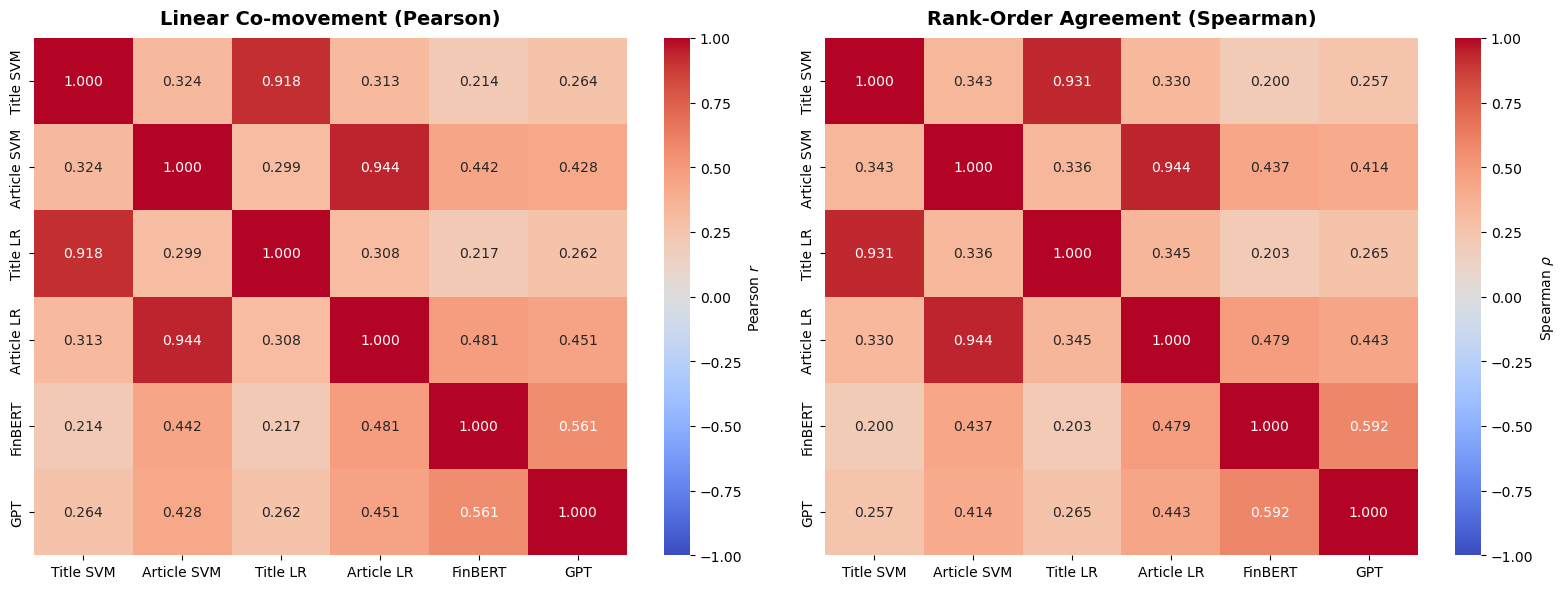

In [29]:
#Plotting Correlation Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Clean labels for the plot
plot_labels = ['Title SVM', 'Article SVM', 'Title LR', 'Article LR', 'FinBERT','GPT']

#Pearson Heatmap
sns.heatmap(news_pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",
            xticklabels=plot_labels, yticklabels=plot_labels, ax=axes[0], cbar_kws={'label': 'Pearson $r$'})
axes[0].set_title('Linear Co-movement (Pearson)', fontsize=14, fontweight='bold', pad=10)

#Spearman Heatmap
sns.heatmap(news_spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",
            xticklabels=plot_labels, yticklabels=plot_labels, ax=axes[1], cbar_kws={'label': 'Spearman $\\rho$'})
axes[1].set_title('Rank-Order Agreement (Spearman)', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('News_sentiment_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

1. The Deep Learning Alignment Block, $0.561$ correlation between finbert_net_score and gpt_net_sentiment.In the context of noisy financial media text, this represents a highly robust, statistically significant moderate-to-strong alignment.It proves that despite vastly different architectures, a discriminative domain-specific encoder vs. a generative LLM—the two models share a highly consistent semantic foundation when extracting continuous sentiment values.

2. Weak correlation between titles and articles reveals that headlines and article bodies do not convey uniform sentiment signal patterns. Headlines are often compressed, direct, or sensationalized, while the article bodies contain nuanced qualifying context, financial metrics, and forward-looking risks.

3. FinBERT and GPT correlates better with articles vs headlines.  The contextual representations inside FinBERT and GPT thrive on dense, unstructured textual inputs. They are far more effective at aligning with traditional features when processed across an expansive sequence length (the full article) rather than short, syntax-sparse phrases (the headline).

4. The correlation between title_svm and title_lr is a staggering $0.9182$, and for articles, it is $0.9439$. This confirms extreme multicollinearity between your traditional classifiers. SVM and Logistic Regression are extracting nearly identical linear decision boundaries from your TF-IDF vectors.

Pearson correlation between FinBERT and GPT was 0.561. Under Spearman, it climbs directly to 0.592, this jump is highly meaningful. It proves that while FinBERT and GPT might disagree slightly on the absolute linear distance of a sentiment score they exhibit an even higher agreement on the ranking of the news. They fundamentally agree on which articles are "highly bearish," "mildly bullish," or "completely neutral."

There is no significant differences for the ML models. This confirms that changing the evaluation lens from linear values to ordinal ranks does not alter the baseline behavior. SVM and Logistic Regression are structurally bound to the same token-matching boundaries, reinforcing that the deep learning models are the true sources of alternative signal variance.

In [30]:
#Correlation Matrices - ECT
ect_pearson_corr = master_dataset_ect[ect_cols].corr(method='pearson')
ect_spearman_corr = master_dataset_ect[ect_cols].corr(method='spearman')

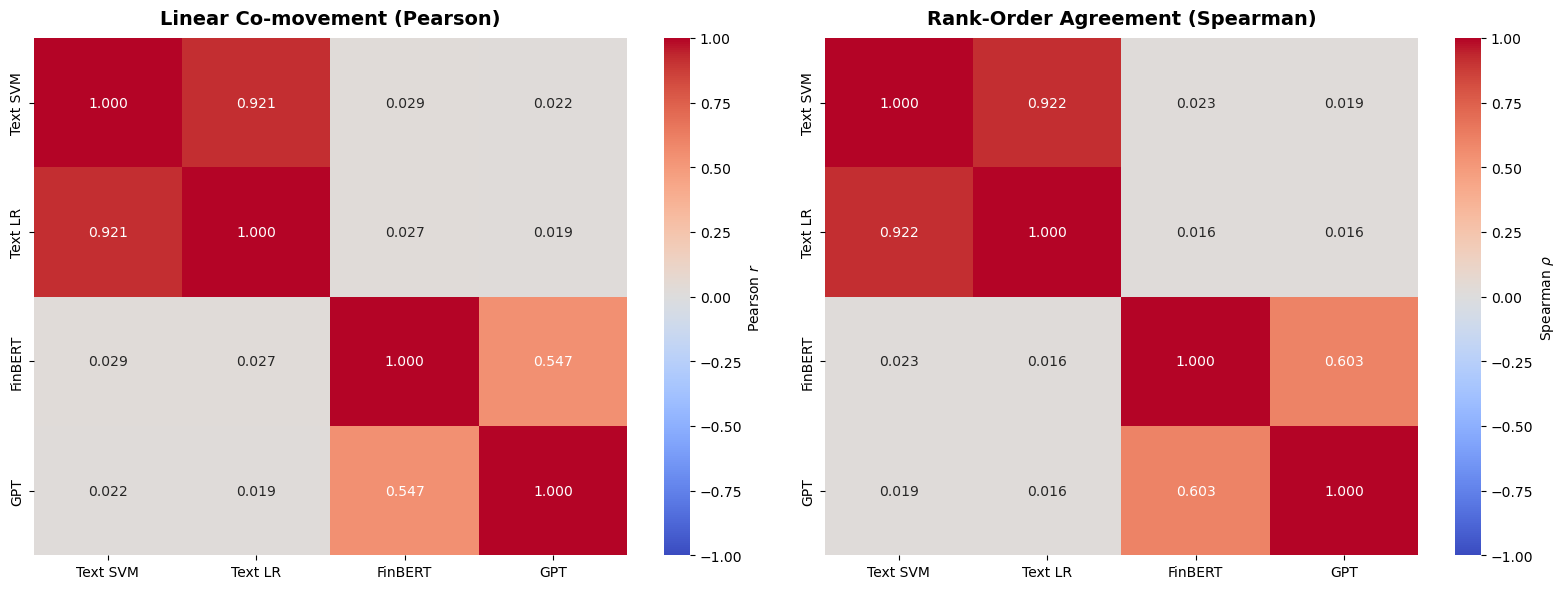

In [31]:
#Plotting Correlation Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Clean labels for the plot
plot_labels = ['Text SVM', 'Text LR', 'FinBERT','GPT']

#Pearson Heatmap
sns.heatmap(ect_pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",
            xticklabels=plot_labels, yticklabels=plot_labels, ax=axes[0], cbar_kws={'label': 'Pearson $r$'})
axes[0].set_title('Linear Co-movement (Pearson)', fontsize=14, fontweight='bold', pad=10)

#Spearman Heatmap
sns.heatmap(ect_spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",
            xticklabels=plot_labels, yticklabels=plot_labels, ax=axes[1], cbar_kws={'label': 'Spearman $\\rho$'})
axes[1].set_title('Rank-Order Agreement (Spearman)', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('ECT_sentiment_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

The correlation between traditional models (SVM/LR) and deep learning models (FinBERT/GPT) completely collapses to near-zero (0.02).Why this happens: Traditional models are trained on raw bag-of-words or TF-IDF tokens. Corporate earnings transcripts are famously packed with optimistic corporate jargon.Because traditional models lack a deep contextual understanding, they get overwhelmed by this standard executive vocabulary and cannot differentiate between superficial optimistic phrasing and genuine operational success. They assign sentiment scores that are entirely un-correlated with the actual linguistic understanding captured by the transformers.

FinBERT and GPT maintain a robust, steady correlation of 0.547.This proves that even when faced with highly manicured corporate speak, FinBERT and GPT still see the same underlying reality. A

SVM and Logistic Regression still correlate at 0.922. This confirms that their counting-based token lookup method behaves exactly the same way across both text datasets, offering no new analytical variance when moving from news to transcripts.

A Spearman rank correlation of 0.60 represents an exceptionally strong consensus between FinBERT and GPT for unstructured corporate speech. it proves that both models agree nearly $60\%$ of the time on which transcripts are the most bearish or bullish overall. The Traditional Flaw is Statistically Locked ($\rho \approx 0.02$)Switching to ranks does absolutely nothing to bridge the gap between traditional ML and deep learning. The correlation remains entirely flat at 0.01 to 0.02. This locks in the conclusion that classical bag-of-words models are fundamentally incapable of extracting the same contextual hierarchy from earnings calls that transformers do. It isn't a scale issue; they are genuinely reading completely different signals.

### Distributions

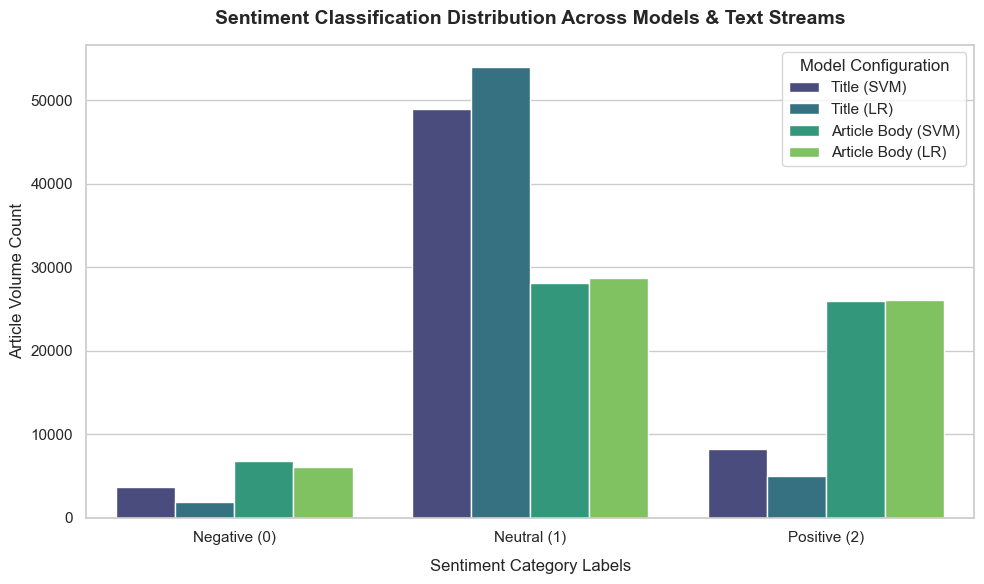

In [32]:
#Sentiment Distribution - ML News Features
dist_df = master_dataset_news[['title_svm_label', 'title_lr_label', 'article_svm_label', 'article_lr_label']].melt(
    var_name='Model_Type', value_name='Sentiment_Class'
)

#Cleaning up column names for better display
name_map = {
    'title_svm_label': 'Title (SVM)',
    'title_lr_label': 'Title (LR)',
    'article_svm_label': 'Article Body (SVM)',
    'article_lr_label': 'Article Body (LR)'
}
dist_df['Model_Type'] = dist_df['Model_Type'].map(name_map)

#Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=dist_df, 
    x='Sentiment_Class', 
    hue='Model_Type', 
    palette='viridis'
)

plt.title('Sentiment Classification Distribution Across Models & Text Streams', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category Labels', fontsize=12, labelpad=10)
plt.ylabel('Article Volume Count', fontsize=12)
plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.legend(title='Model Configuration', frameon=True)

plt.tight_layout()
#plt.savefig('sentiment_distribution_comparison.png', dpi=300)
plt.show()

Both models display an extensive clustering of classifications within the Neutral (1) category, with this concentration becoming significantly more pronounced in the Title text stream than in the Article text stream. This behavior exposes the inherent structural limitations of static word-frequency modeling (TF-IDF). Because headlines are structurally brief and syntax-sparse, they rarely contain a critical mass of explicit sentiment tokens, forcing the token-matching classifiers to default to the baseline neutral class. When moving to full articles, the expanded sequence length introduces a higher density of polarized words, allowing the traditional models to map more rows away from the center. This starkly contrasts with the deep learning models (FinBERT and GPT), which process non-linear contextual hierarchies independently of sequence length, demonstrating their superior capacity for parsing short-form financial disclosures

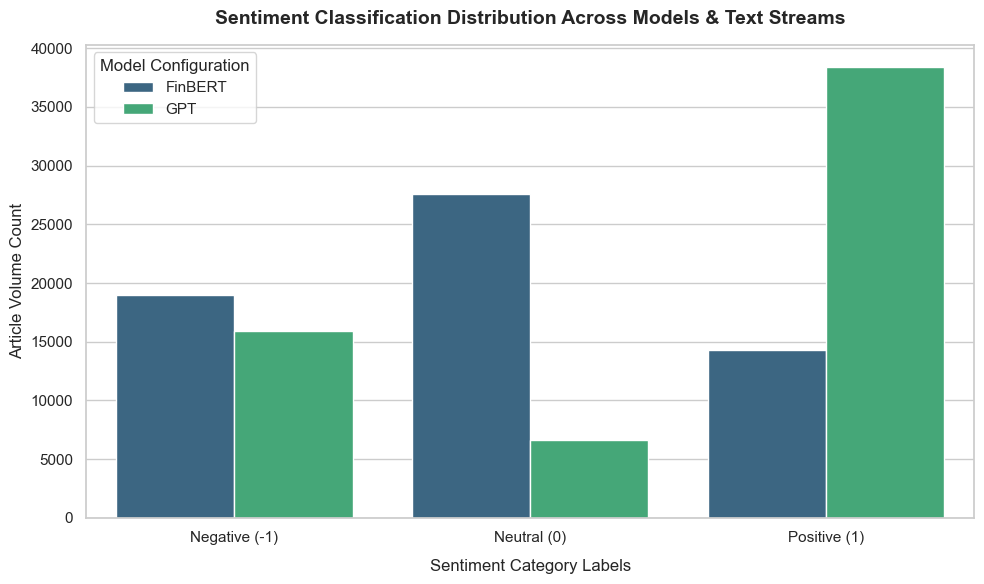

In [33]:
#Sentiment Distribution - LLM News Features
dist_df = master_dataset_news[['finbert_hard_label', 'gpt_hard_label']].melt(
    var_name='Model_Type', value_name='Sentiment_Class'
)

# Explicitly cast to integer and drop missing records to secure clean axis sorting
dist_df['Sentiment_Class'] = dist_df['Sentiment_Class'].dropna().astype(int)

# Cleaning up column names for better display
name_map = {
    'finbert_hard_label': 'FinBERT',
    'gpt_hard_label': 'GPT'
}
dist_df['Model_Type'] = dist_df['Model_Type'].map(name_map)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=dist_df, 
    x='Sentiment_Class', 
    hue='Model_Type', 
    order=[-1, 0, 1],
    palette='viridis'
)

plt.title('Sentiment Classification Distribution Across Models & Text Streams', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category Labels', fontsize=12, labelpad=10)
plt.ylabel('Article Volume Count', fontsize=12)
# corresponding exactly to the sequence array mapped inside the `order` parameter above.
plt.xticks([0, 1, 2], ['Negative (-1)', 'Neutral (0)', 'Positive (1)'])
plt.legend(title='Model Configuration', frameon=True)
plt.tight_layout()
plt.savefig('LLM_News_distribution_comparison.png', dpi=300)
plt.show()

This reveals distinct structural divergence in how the two transformer architectures allocate categorical hard labels across the news corpus. FinBERT displays a pronounced concentration of Neutral (0) classifications. This reflects its specialized discriminative fine-tuning, which isolates objective, non-tonal financial reporting from active sentiment shifts. Conversely, GPT exhibits a significantly higher density of Positive (1) classifications, demonstrating its generalized generative tendency to infer systemic optimism from standard corporate progress updates. Crucially, both models achieve near-parity in their distribution of Negative (-1) labels. This symmetric floor indicates that while positive and neutral contexts are subject to architectural interpretation variance, downside financial risk is conveyed via explicit linguistic markers that are uniformly recognized across both models.

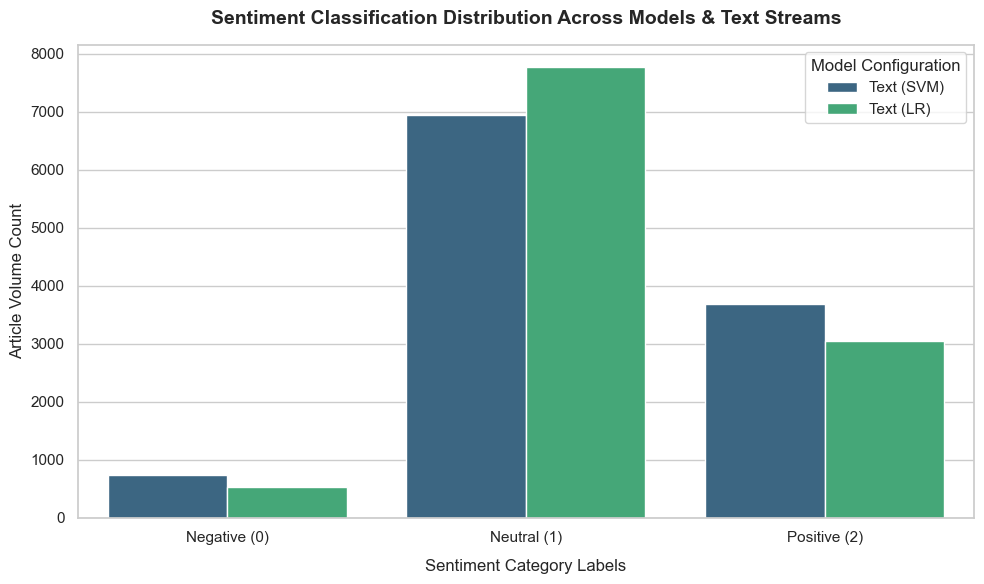

In [34]:
#Sentiment Distribution - ECT ML Features
#Ensures DataFrame is compatible with Seaborn's hue mapping
dist_df = master_dataset_ect[['txt_svm_label', 'txt_lr_label']].melt(
    var_name='Model_Type', value_name='Sentiment_Class'
)

#Cleaning up column names for better display
name_map = {
    'txt_svm_label': 'Text (SVM)',
    'txt_lr_label': 'Text (LR)'
}
dist_df['Model_Type'] = dist_df['Model_Type'].map(name_map)

#Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=dist_df, 
    x='Sentiment_Class', 
    hue='Model_Type', 
    palette='viridis'
)

plt.title('Sentiment Classification Distribution Across Models & Text Streams', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category Labels', fontsize=12, labelpad=10)
plt.ylabel('Article Volume Count', fontsize=12)
plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.legend(title='Model Configuration', frameon=True)

plt.tight_layout()
#plt.savefig('sentiment_distribution_granular.png', dpi=300)
plt.show()

The categorical distribution of the ML models across the corporate transcript corpus exhibits a dominant concentration of Neutral classifications, followed by a moderate Positive distribution, and an exceptionally sparse Negative footprint. This composition directly aligns with the behavioral patterns of executive communications, where corporate management heavily employs strategic, optimistic language to discuss operational milestones while strictly minimizing overt negative indicators.

However, the overwhelming monopoly of the Neutral class across the SVM and Logistic Regression configurations highlights the lexical dilution flaw of token-matching frameworks. Because earnings call transcripts are heavily saturated with administrative, accounting, and legal boilerplate text, the traditional models' TF-IDF vectorizers are mathematically anchored to non-tonal background frequencies. While deep learning transformers (FinBERT and GPT) successfully leverage semantic attention layers to isolate the executive optimism and lift their distributions into the positive spectrum, traditional classifiers get muted by the technical vocabulary, under-reporting the true narrative tone of the disclosure.

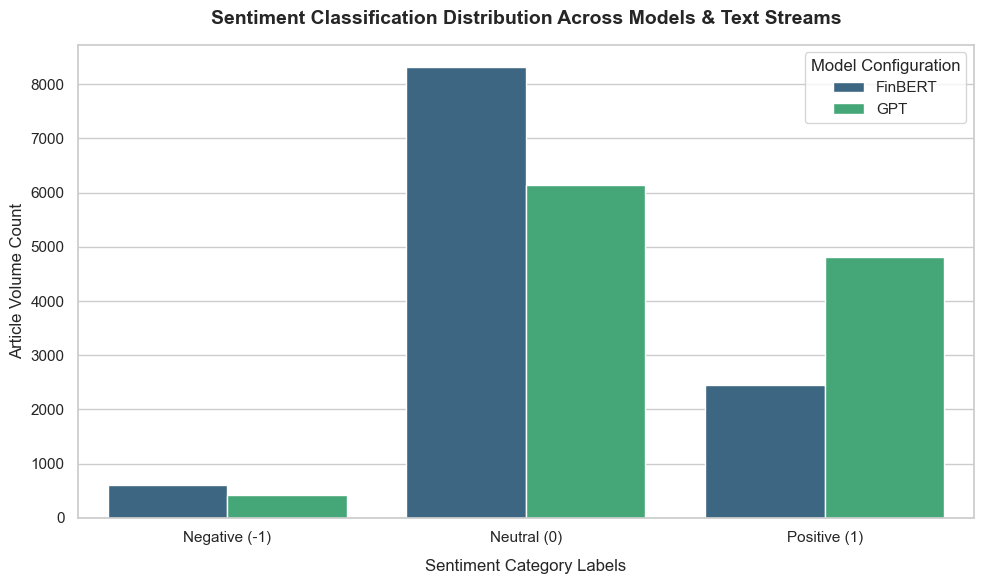

In [35]:
#Sentiment Distribution - ECT LLM Features
dist_df = master_dataset_ect[['finbert_hard_label', 'gpt_hard_label']].melt(
    var_name='Model_Type', value_name='Sentiment_Class'
)

#Cleaning up column names for better display
name_map = {
    'finbert_hard_label': 'FinBERT',
    'gpt_hard_label': 'GPT'
}
dist_df['Model_Type'] = dist_df['Model_Type'].map(name_map)

#Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=dist_df, 
    x='Sentiment_Class', 
    hue='Model_Type', 
    order=[-1, 0, 1],
    palette='viridis'
)

plt.title('Sentiment Classification Distribution Across Models & Text Streams', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Category Labels', fontsize=12, labelpad=10)
plt.ylabel('Article Volume Count', fontsize=12)
plt.xticks([0, 1, 2], ['Negative (-1)', 'Neutral (0)', 'Positive (1)'])
plt.legend(title='Model Configuration', frameon=True)
plt.tight_layout()
plt.savefig('LLM_ECT_distribution_granular.png', dpi=300)
plt.show()

FinBERT concentrates its output mass within the Neutral domain, whereas GPT shifts its modal frequency directly into the Positive and Neutral classification. This divergence maps directly to the models' underlying architectural constraints. FinBERT, fine-tuned on concise financial news matrices, relies on localized, explicit token markers to validate sentiment transitions; it thus penalizes the expansive, conversational boilerplate of spoken executive transcripts by defaulting them to Neutral. Conversely, GPT’s generative architecture possesses a broader contextual field, enabling it to decode the pragmatic intent of corporate communication. GPT identifies the tactical optimism, safe-harbor forward guidance, and strategic framing employed by corporate management, subsequently differentiating Positive and Neutral classifications.

### Trajectory

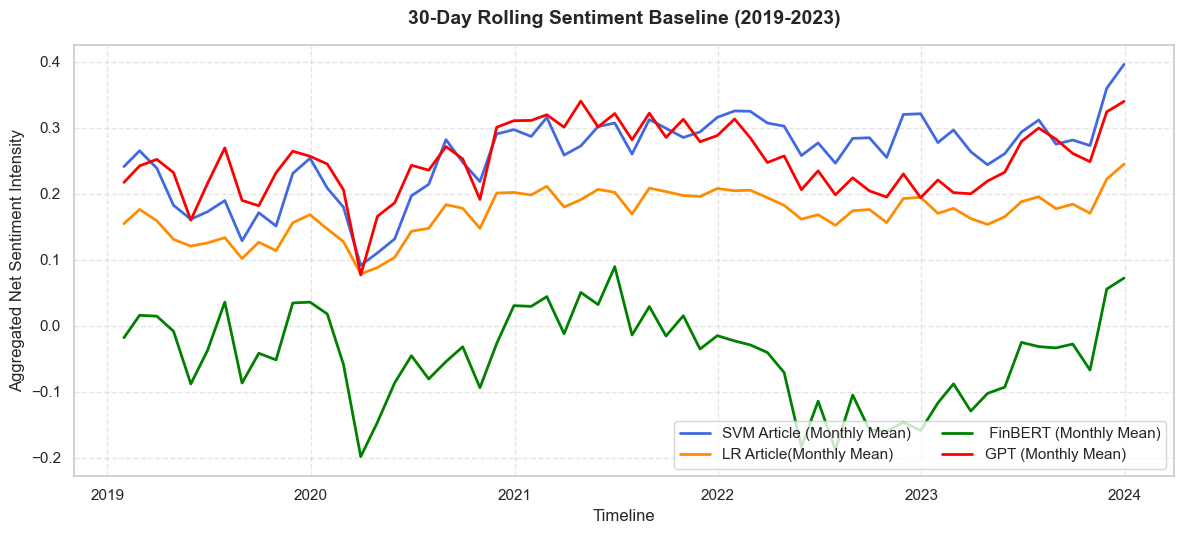

In [36]:
#Sentiment Trajectory Plot - Title
time_df = master_dataset_news[['date', 'article_svm_net_sentiment', 'article_lr_net_sentiment','finbert_net_score','gpt_net_sentiment']].copy()
time_df['date'] = pd.to_datetime(time_df['date'])
time_df.set_index('date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['article_svm_net_sentiment'], label='SVM Article (Monthly Mean)', color='royalblue', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['article_lr_net_sentiment'], label='LR Article(Monthly Mean)', color='darkorange', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['finbert_net_score'], label=' FinBERT (Monthly Mean)', color='green', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['gpt_net_sentiment'], label='GPT (Monthly Mean)', color='red', linewidth=2)

plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('llm and article_sentiment_timeline.png', dpi=300)
plt.show()

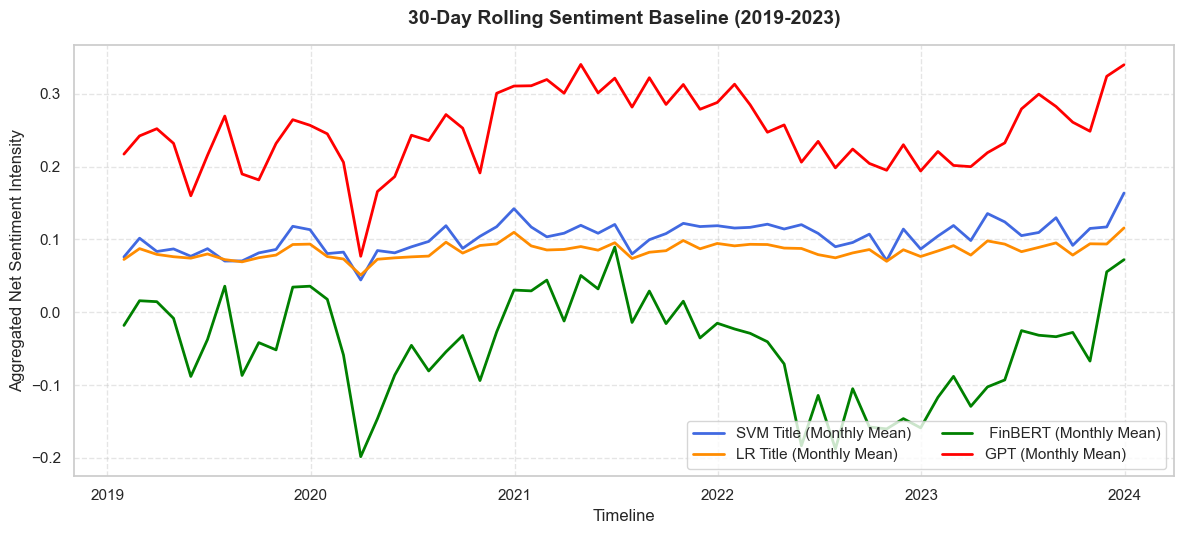

In [37]:
#Sentiment Trajectory Plot - Title
time_df = master_dataset_news[['date', 'title_svm_net_sentiment', 'title_lr_net_sentiment','finbert_net_score','gpt_net_sentiment']].copy()
time_df['date'] = pd.to_datetime(time_df['date'])
time_df.set_index('date', inplace=True)

#Resample to Monthly Average to smooth out daily noise for a clean display
monthly_sentiment = time_df.resample('ME').mean() #Month End

plt.figure(figsize=(12, 5.5))
plt.plot(monthly_sentiment.index, monthly_sentiment['title_svm_net_sentiment'], label='SVM Title (Monthly Mean)', color='royalblue', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['title_lr_net_sentiment'], label='LR Title (Monthly Mean)', color='darkorange', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['finbert_net_score'], label=' FinBERT (Monthly Mean)', color='green', linewidth=2)
plt.plot(monthly_sentiment.index, monthly_sentiment['gpt_net_sentiment'], label='GPT (Monthly Mean)', color='red', linewidth=2)

plt.title('30-Day Rolling Sentiment Baseline (2019-2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Aggregated Net Sentiment Intensity', fontsize=12)
plt.legend(loc='lower right', frameon=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('llm and title macro_sentiment_timeline.png', dpi=300)
plt.show()

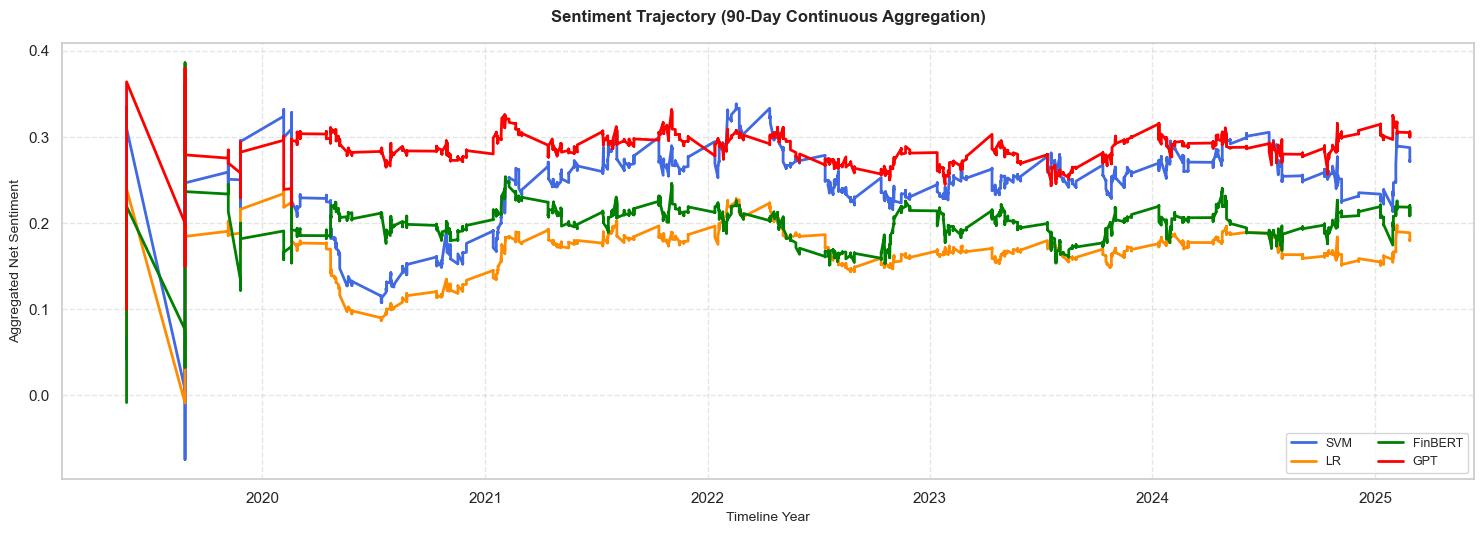

In [38]:
#Trajectory
time_df = master_dataset_ect[['calendar_date','txt_svm_net_sentiment','txt_lr_net_sentiment','finbert_net_score','gpt_net_sentiment']].copy()
time_df['calendar_date'] = pd.to_datetime(time_df['calendar_date'])

#Sorting chronologically
time_df.sort_values('calendar_date', inplace=True)
time_df.set_index('calendar_date', inplace=True)

#Applying a 90-Day Continuous Rolling Mean min_periods=1 guards against empty weekend slots
rolling_sentiment = time_df.rolling(window='90D', min_periods=1).mean()

plt.rcParams['figure.figsize'] = (15, 5.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(rolling_sentiment.index, rolling_sentiment['txt_svm_net_sentiment'], label='SVM', color='royalblue', linewidth=2)
plt.plot(rolling_sentiment.index, rolling_sentiment['txt_lr_net_sentiment'], label='LR', color='darkorange', linewidth=2)
plt.plot(rolling_sentiment.index, rolling_sentiment['finbert_net_score'], label='FinBERT', color='green', linewidth=2)
plt.plot(rolling_sentiment.index, rolling_sentiment['gpt_net_sentiment'], label='GPT', color='red', linewidth=2)


#Formatting
plt.title('Sentiment Trajectory (90-Day Continuous Aggregation)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline Year', fontsize=10)
plt.ylabel('Aggregated Net Sentiment', fontsize=10)
plt.legend(loc='lower right', frameon=True, ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('models_ECT_sentiment_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

### Net Distributions

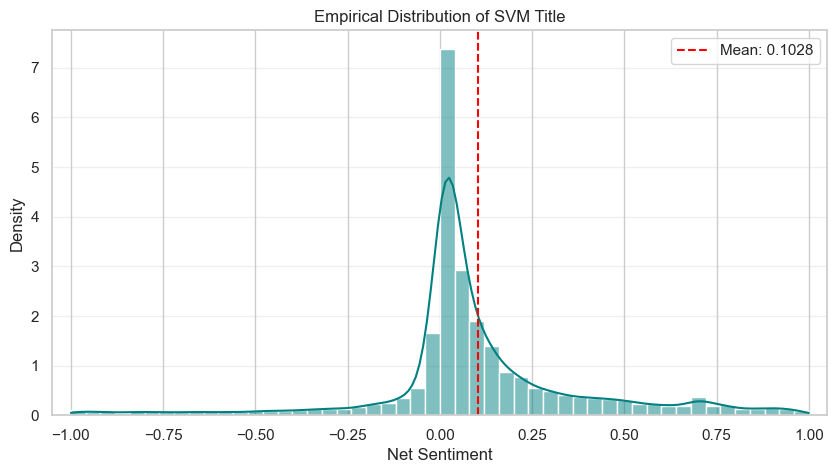

In [39]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(master_dataset_news['title_svm_net_sentiment'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(master_dataset_news['title_svm_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {master_dataset_news['title_svm_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of SVM Title', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution SVM Title.png', dpi=300)
plt.show()

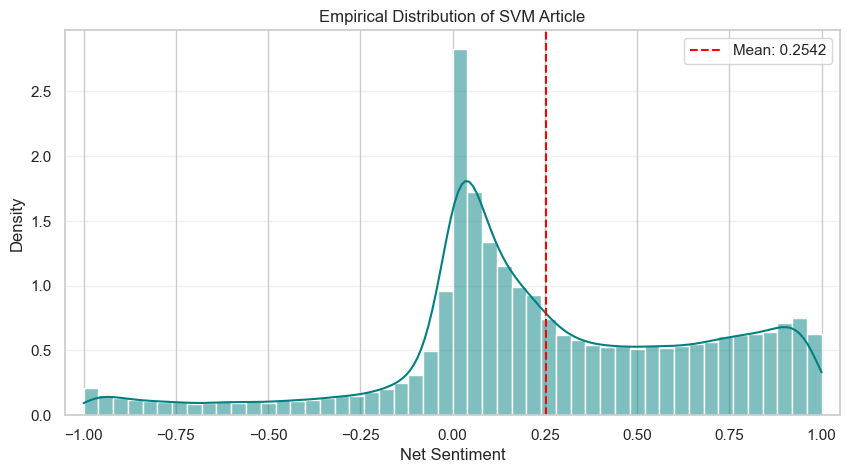

In [40]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(master_dataset_news['article_svm_net_sentiment'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(master_dataset_news['article_svm_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {master_dataset_news['article_svm_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of SVM Article', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution SVM Article.png', dpi=300)
plt.show()

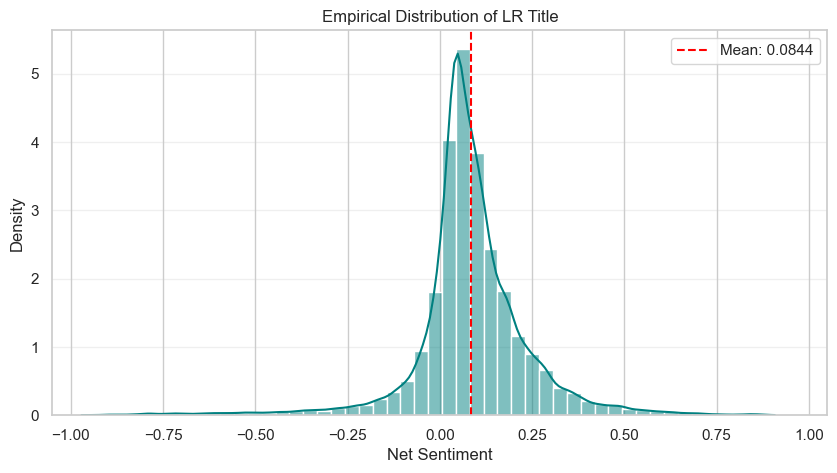

In [41]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(master_dataset_news['title_lr_net_sentiment'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(master_dataset_news['title_lr_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {master_dataset_news['title_lr_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of LR Title', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution LR Title.png', dpi=300)
plt.show()

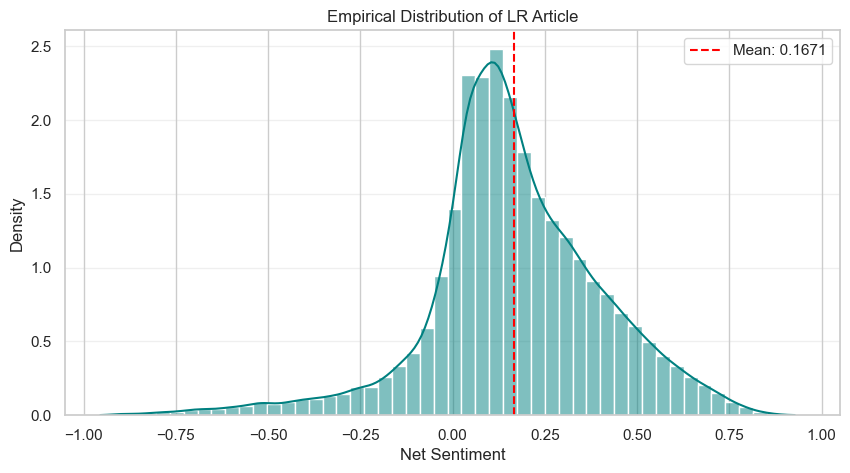

In [42]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(master_dataset_news['article_lr_net_sentiment'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(master_dataset_news['article_lr_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {master_dataset_news['article_lr_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of LR Article', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution LR Article.png', dpi=300)
plt.show()

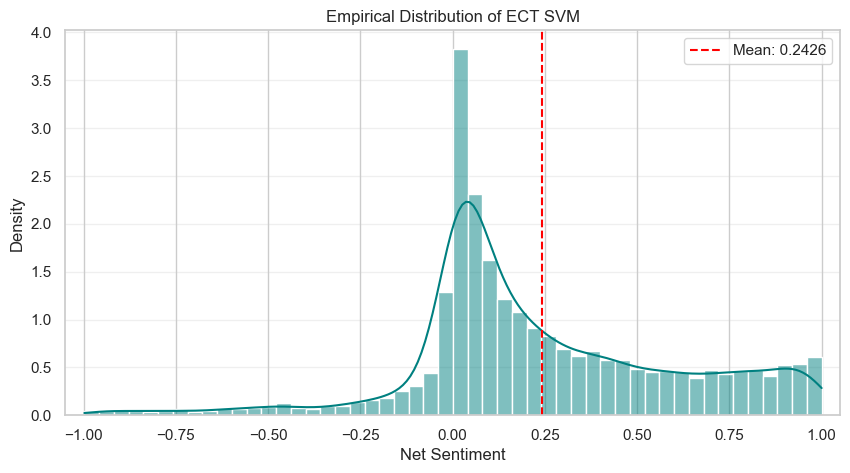

In [43]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(master_dataset_ect['txt_svm_net_sentiment'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(master_dataset_ect['txt_svm_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {master_dataset_ect['txt_svm_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of ECT SVM', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution ECT SVM.png', dpi=300)
plt.show()

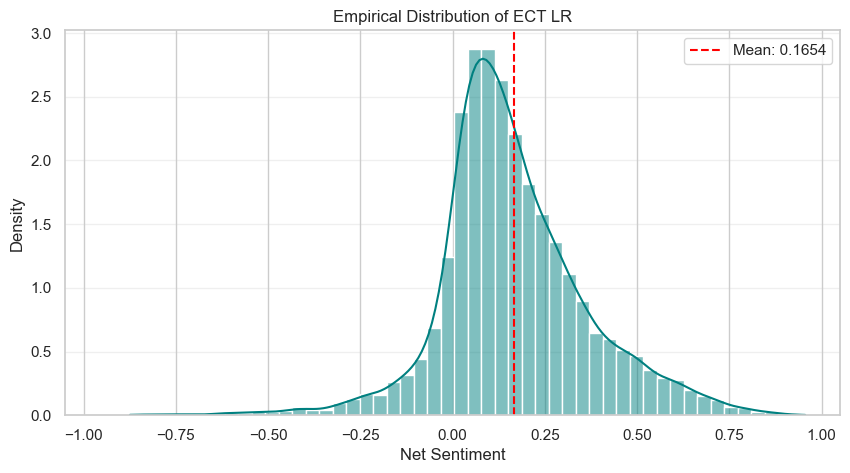

In [44]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(master_dataset_ect['txt_lr_net_sentiment'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(master_dataset_ect['txt_lr_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {master_dataset_ect['txt_lr_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of ECT LR', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution ECT LR.png', dpi=300)
plt.show()

This visually demonstrates that the model successfully differentiates strong sentiment from baseline noise. Nature of financial news is not always neutral and the model can clearly separate strong positive or negative market news. This will ensure the prediction model can capture this variance for stock market prediction. Looking closely at the distribution around $-0.8$ and $+0.8$, it confirms that the FinBERT model is successfully detecting strong sentiment signals instead of diluting everything toward a flat normal curve.

There is a slight difference between dataset A & B distributions, Dataset A tends to have a higher density at neutral which can be attributed to the fact that the data had more noise as dataset B was further filtered to retain only relevant news.

This plot above visualizes the distribution of the Net Scores across the theoretical [-1, +1] spectrum, overlaying a Kernel Density Estimate (KDE) and an explicit marker for the mean. This checks for a bimodal distribution vs. a normal distribution. We can see the net scores pile up around 0.0 (neutral news) but also positive.

In [45]:
#Saving Data with Sentiment Scores
output_path1 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\News\master_news_sentiments.csv'
output_path2 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\master_ect_sentiments.csv'
master_dataset_news.to_csv(output_path1, index=False)
master_dataset_ect.to_csv(output_path2, index=False)
print('Success!')

Success!
